# Monte Carlo Interest Rate Paths
## Short Rate Models — Vasicek and Hull-White with Antithetic Sampling

This notebook simulates interest rate paths under two foundational short rate models:

- **Vasicek (1977)** — the simplest analytically tractable mean-reverting model  
- **Hull-White (1990)** — extends Vasicek to fit the current OIS term structure exactly

Including:
- Maths derivation from first principles
- Euler-Maruyama discretisation
- exact simulation side-by-side, 
- calibrate Hull-White to the live OIS curve, 
- demonstrate antithetic variates as a variance reduction technique

The production classes `VasicekProcess` and `HullWhiteProcess` in `src/quant_risk/models/rates.py` implement everything shown here. This notebook is the worked explanation of the theory behind them.

---

**Why simulate short rates?**

Short rate paths are the input to every XVA metric in Module 3. Under future rate scenarios we need to know what a swap or bond is worth. That is, we need the distribution of the mark-to-market across time and across paths. Specifically:

| Downstream use | What is needed from this notebook |
|---|---|
| CVA (QRE-53) | Distribution of future swap/bond MTM under rate scenarios |
| FVA (QRE-54) | Expected Positive/Negative Exposure profiles |
| MVA (QRE-55) | Initial margin path — requires simulated sensitivities |
| IRRBB stress | EVE/NII under prescribed EBA shocks (already implemented in Module 1) |

---

**Notebook structure**
1. **Vasicek model**: SDE, analytical solution, parameter interpretation
2. **Discretisation**: Euler-Maruyama from scratch, then exact simulation
3. **Hull-White model**: calibration to the OIS forward curve
4. **Antithetic variates**: variance reduction theory and convergence analysis
5. Production infrastructure: `VasicekProcess` and `HullWhiteProcess` from `src/`

In [13]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from quant_risk.setup import base
np, pd, plt = base()

# Random seed used throughout for reproducibility
RNG_SEED = 42

base loaded


---
## 1. The Vasicek Model

### 1.1 Stochastic Differential Equation

The Vasicek model (Vasicek, 1977) describes the instantaneous short rate $r(t)$ as an Ornstein-Uhlenbeck process:

$$dr(t) = \kappa\bigl(\theta - r(t)\bigr)\,dt + \sigma\,dW(t)$$

where:

| Symbol | Name | Units | Typical EUR range |
|---|---|---|---|
| $\kappa > 0$ | Mean reversion speed | year$^{-1}$ | 0.05 – 0.5 |
| $\theta$ | Long-run mean rate | % | 1.5 – 4.0 |
| $\sigma > 0$ | Instantaneous volatility | %/$\sqrt{\text{year}}$ | 0.3 – 1.5 |
| $W(t)$ | Standard Brownian motion | — | under $\mathbb{Q}$ |

The drift term $\kappa(\theta - r)$ is a **restoring force**: when $r > \theta$ the drift is negative (rates pulled down); when $r < \theta$ the drift is positive (rates pulled up). The strength of this force is proportional to the displacement from $\theta$.

### 1.2 Analytical Solution

The SDE is linear in $r(t)$, so it can be solved exactly. Multiplying both sides by the integrating factor $e^{\kappa t}$ and integrating:

$$r(t) = r(0)\,e^{-\kappa t} + \theta\bigl(1 - e^{-\kappa t}\bigr) + \sigma\int_0^t e^{-\kappa(t-s)}\,dW(s)$$

The three terms are:
1. **Memory of $r(0)$**: the initial rate, decaying exponentially toward zero
2. **Long-run mean**: $\theta$ growing from zero, completing the mean reversion
3. **Stochastic integral**: Gaussian, mean $0$, variance $\frac{\sigma^2}{2\kappa}(1 - e^{-2\kappa t})$

### 1.3 Distributional Properties

Since the stochastic integral is Gaussian, $r(t)$ is normally distributed for all $t$:

$$r(t) \sim \mathcal{N}\!\left(\mu(t),\; v^2(t)\right)$$

$$\mu(t) = r(0)\,e^{-\kappa t} + \theta\bigl(1 - e^{-\kappa t}\bigr) \qquad v^2(t) = \frac{\sigma^2}{2\kappa}\bigl(1 - e^{-2\kappa t}\bigr)$$

As $t \to \infty$: $\mu \to \theta$, $v^2 \to \sigma^2/(2\kappa)$ — the **stationary distribution**.

### 1.4 One-Step Transition: the Basis for Exact Simulation

The conditional distribution over one time step $\Delta t$ follows directly from the analytical solution:

$$r(t+\Delta t)\,\big|\,r(t) \;\sim\; \mathcal{N}\!\left(\mu_{\Delta t},\; v^2_{\Delta t}\right)$$

$$\mu_{\Delta t} = r(t)\,e^{-\kappa\Delta t} + \theta\bigl(1 - e^{-\kappa\Delta t}\bigr)$$

$$v^2_{\Delta t} = \frac{\sigma^2}{2\kappa}\bigl(1 - e^{-2\kappa\Delta t}\bigr)$$

This is **exact** — no approximation, regardless of step size $\Delta t$.

### 1.5 Known Limitation: Negative Rates

Because $r(t)$ is normally distributed, it can go negative with positive probability. In EUR, this was economically relevant during the 2014–2022 negative rate period, so it is not necessarily a disqualifying limitation. The Cox-Ingersoll-Ross (CIR) model and its variants enforce non-negativity through a square-root diffusion, at the cost of analytical tractability.

In [2]:
# ── Model parameters ─────────────────────────────────────────────────────────
# Representative EUR short rate parameters for a 2026 environment:
#   κ = 0.1  → half-life of mean reversion = ln(2)/κ ≈ 7 years (slow reversion)
#   θ = 2.5% → consistent with ECB depo rate trajectory
#   σ = 0.5% → moderate, calibrated to ATM swaption volatility surface
kappa = 0.10   # mean reversion speed (1/year)
theta = 2.50   # long-run mean rate (percent)
sigma = 0.50   # volatility (%/√year)

r0 = 2.50      # initial short rate = θ for clarity (no initial bias)
T  = 5.0       # simulation horizon (years) — covers typical swap tenor for CVA
N  = 200       # number of time steps
dt = T / N     # step size in years

# Pre-compute the time grid for plotting
t_grid = np.linspace(0, T, N + 1)

print(f"Step size:         dt = {dt:.4f} years = {dt*365:.1f} days")
print(f"Mean-reversion half-life: {np.log(2)/kappa:.1f} years")
print(f"Stationary std dev:       {sigma/np.sqrt(2*kappa):.4f}%")
print(f"Pr(r < 0) in stationary:  {stats.norm.cdf(0, theta, sigma/np.sqrt(2*kappa))*100:.4f}%")

Step size:         dt = 0.0250 years = 9.1 days
Mean-reversion half-life: 6.9 years
Stationary std dev:       1.1180%
Pr(r < 0) in stationary:  1.2674%


---
## 2. Discretisation: Euler-Maruyama

### 2.1 The General Scheme

For a general Itô SDE $dX = \mu(X,t)\,dt + \sigma(X,t)\,dW$, the **Euler-Maruyama** scheme approximates the path at discrete times $t_i = i\,\Delta t$:

$$X(t_{i+1}) \approx X(t_i) + \mu\bigl(X(t_i), t_i\bigr)\,\Delta t + \sigma\bigl(X(t_i), t_i\bigr)\,\sqrt{\Delta t}\;Z_i, \qquad Z_i \overset{\text{iid}}{\sim} \mathcal{N}(0,1)$$

**Convergence rates:**
- **Strong** (pathwise): $\mathbb{E}[|X(T) - \hat{X}(T)|] = O(\sqrt{\Delta t})$  
- **Weak** (distributional): $|\mathbb{E}[f(X(T))] - \mathbb{E}[f(\hat{X}(T))]| = O(\Delta t)$ for smooth $f$

For XVA calculations (expectations of payoffs), **weak order 1** is typically sufficient.

### 2.2 Applied to Vasicek

Substituting $\mu = \kappa(\theta - r)$ and constant $\sigma$:

$$r(t+\Delta t) \approx r(t) + \kappa\bigl(\theta - r(t)\bigr)\,\Delta t + \sigma\sqrt{\Delta t}\;Z$$

This is our baseline implementation. We use the same random draws later for the exact simulation to make the comparison fair.

In [3]:
# ── Vasicek: Euler-Maruyama from scratch ─────────────────────────────────────
# We implement directly from the formula before using the production class,
# so the mapping between mathematics and code is explicit.

n_paths = 500

# Draw all random numbers at once — (paths × steps) matrix of Z ~ N(0,1)
rng = np.random.default_rng(RNG_SEED)
Z   = rng.standard_normal((n_paths, N))

# Initialise path matrix: rows = paths, columns = time steps
paths_euler = np.empty((n_paths, N + 1))
paths_euler[:, 0] = r0   # all paths start at r0

for i in range(N):
    # Drift: mean-reverting force toward θ, scaled by dt
    drift     = kappa * (theta - paths_euler[:, i]) * dt
    # Diffusion: random shock with correct variance σ²·dt
    diffusion = sigma * np.sqrt(dt) * Z[:, i]
    paths_euler[:, i + 1] = paths_euler[:, i] + drift + diffusion

# Compare terminal statistics against the analytical distribution
mu_T    = r0 * np.exp(-kappa*T) + theta * (1 - np.exp(-kappa*T))
sigma_T = sigma * np.sqrt((1 - np.exp(-2*kappa*T)) / (2*kappa))

print("Euler-Maruyama terminal rate statistics")
print(f"  Simulated: mean={paths_euler[:,-1].mean():.4f}%  std={paths_euler[:,-1].std():.4f}%")
print(f"  Analytical: mean={mu_T:.4f}%  std={sigma_T:.4f}%")

Euler-Maruyama terminal rate statistics
  Simulated: mean=2.4538%  std=0.8941%
  Analytical: mean=2.5000%  std=0.8889%


---
## 3. Exact Simulation

Because the Vasicek SDE has a closed-form solution, we can draw directly from the **exact conditional distribution** rather than approximating it:

$$r(t+\Delta t)\,\big|\,r(t) \;=\; r(t)\,e^{-\kappa\Delta t} + \theta\bigl(1-e^{-\kappa\Delta t}\bigr) + v_{\Delta t}\cdot Z$$

where:

$$v_{\Delta t} = \sigma\sqrt{\frac{1 - e^{-2\kappa\Delta t}}{2\kappa}}$$

and $Z \sim \mathcal{N}(0,1)$.

**Key observation**: the conditional mean $\mu_{\Delta t}$ and standard deviation $v_{\Delta t}$ depend only on $(\kappa, \theta, \sigma, \Delta t)$ — not on the current rate $r(t)$. This means they can be **pre-computed once** outside the simulation loop, making exact simulation computationally identical to Euler-Maruyama but with zero discretisation error.

The production `VasicekProcess` class uses this scheme.

In [4]:
# ── Vasicek: exact simulation from scratch ───────────────────────────────────
# Pre-compute the time-invariant constants (depend only on κ, θ, σ, Δt)
exp_neg_kdt = np.exp(-kappa * dt)                        # e^{-κΔt}
mean_adj    = theta * (1.0 - exp_neg_kdt)                # θ(1 - e^{-κΔt})
cond_std    = sigma * np.sqrt(                           # σ√((1-e^{-2κΔt})/(2κ))
    (1.0 - np.exp(-2.0 * kappa * dt)) / (2.0 * kappa)
)

print(f"Pre-computed constants:")
print(f"  e^{{-κΔt}} = {exp_neg_kdt:.6f}")
print(f"  θ(1-e^{{-κΔt}}) = {mean_adj:.6f}%  (drift toward long-run mean per step)")
print(f"  conditional std = {cond_std:.6f}%  (noise per step)")

# Use the SAME random draws as Euler for a fair path-by-path comparison
paths_exact = np.empty((n_paths, N + 1))
paths_exact[:, 0] = r0

for i in range(N):
    # r(t+Δt) = r(t)·e^{-κΔt} + θ(1-e^{-κΔt}) + v_Δt · Z
    paths_exact[:, i + 1] = (
        paths_exact[:, i] * exp_neg_kdt + mean_adj + cond_std * Z[:, i]
    )

print(f"\nExact terminal rate statistics")
print(f"  Simulated: mean={paths_exact[:,-1].mean():.4f}%  std={paths_exact[:,-1].std():.4f}%")
print(f"  Analytical: mean={mu_T:.4f}%  std={sigma_T:.4f}%")
print(f"\nMax path-wise difference |exact - euler|: {np.abs(paths_exact-paths_euler).max():.6f}%")

Pre-computed constants:
  e^{-κΔt} = 0.997503
  θ(1-e^{-κΔt}) = 0.006242%  (drift toward long-run mean per step)
  conditional std = 0.078958%  (noise per step)

Exact terminal rate statistics
  Simulated: mean=2.4538%  std=0.8932%
  Analytical: mean=2.5000%  std=0.8889%

Max path-wise difference |exact - euler|: 0.003094%


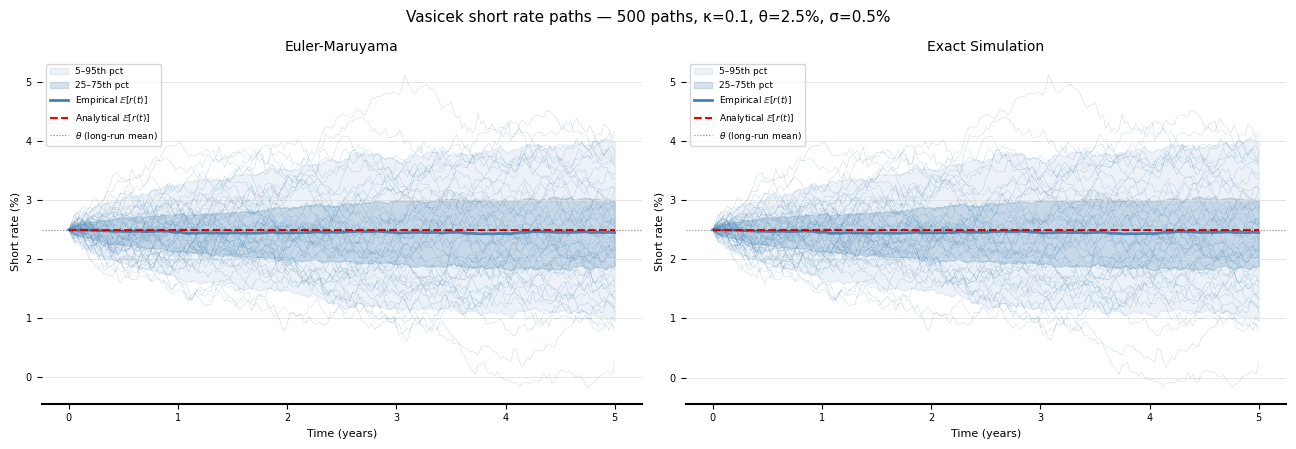

In [ ]:
# ── Fan charts: Euler-Maruyama vs Exact ──────────────────────────────────────
# Analytical mean and ±1σ / ±2σ bands for overlay
mu_t    = r0 * np.exp(-kappa*t_grid) + theta*(1 - np.exp(-kappa*t_grid))
sigma_t = sigma * np.sqrt((1 - np.exp(-2*kappa*t_grid)) / (2*kappa))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(f"Vasicek short rate paths — {n_paths} paths, κ={kappa}, θ={theta}%, σ={sigma}%",
             fontsize=11)

for ax, paths, title in zip(axes, [paths_euler, paths_exact], ["Euler-Maruyama", "Exact Simulation"]):
    # 50 individual paths as thin lines (visual context)
    for i in range(50):
        ax.plot(t_grid, paths[i], lw=0.3, alpha=0.35, color='steelblue')

    # Empirical percentile bands
    p5,  p95 = np.percentile(paths, [5,  95], axis=0)
    p25, p75 = np.percentile(paths, [25, 75], axis=0)
    ax.fill_between(t_grid, p5,  p95,  alpha=0.10, color='steelblue', label="5–95th pct")
    ax.fill_between(t_grid, p25, p75,  alpha=0.22, color='steelblue', label="25–75th pct")

    # Empirical mean vs analytical mean
    ax.plot(t_grid, paths.mean(axis=0), lw=2.0, color='steelblue', label=r"Empirical $\mathbb{E}[r(t)]$")
    ax.plot(t_grid, mu_t,               lw=1.5, color='red',       ls='--', label=r"Analytical $\mathbb{E}[r(t)]$")
    ax.axhline(theta, lw=0.8, color='black', ls=':', alpha=0.5, label=r"$\theta$ (long-run mean)")

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Short rate (%)")
    ax.set_title(title)
    ax.legend(fontsize=6.5)

plt.tight_layout()
plt.show()

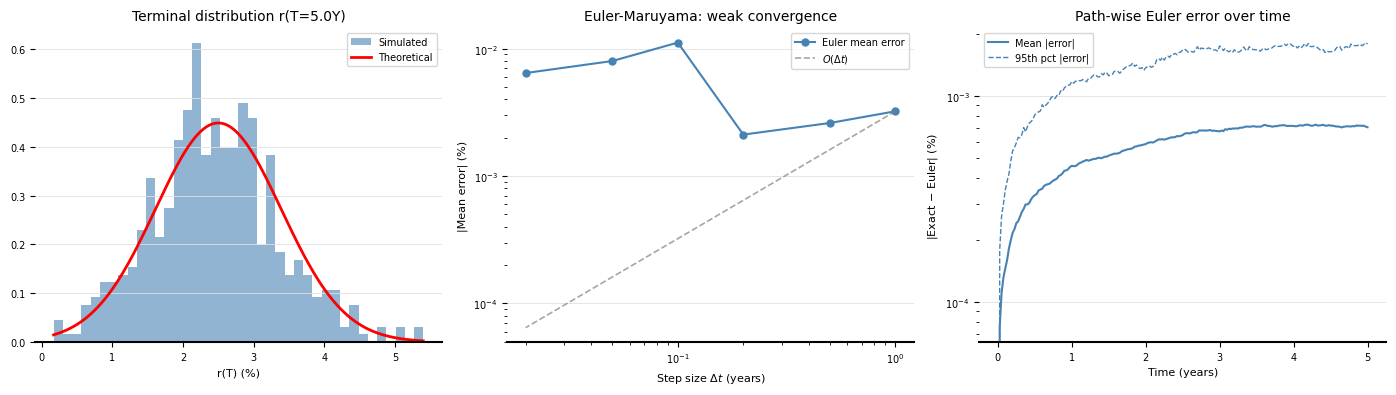

Both schemes converge to the same distribution, but path-by-path differences accumulate.
For pricing (weak convergence), Euler is fine. For path-dependent payoffs, exact is preferred.


In [6]:
# ── Euler convergence and terminal distribution ───────────────────────────────
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14, 4))

# Left: terminal distribution vs theoretical Normal
ax = ax0
ax.hist(paths_exact[:, -1], bins=40, density=True, alpha=0.6, color='steelblue', label="Simulated")
x_range = np.linspace(paths_exact[:, -1].min(), paths_exact[:, -1].max(), 300)
ax.plot(x_range, stats.norm.pdf(x_range, mu_T, sigma_T), lw=2.0, color='red', label="Theoretical")
ax.set_xlabel("r(T) (%)")
ax.set_title(f"Terminal distribution r(T={T}Y)")
ax.legend()

# Middle: Euler weak convergence — mean error vs step size
ax = ax1
step_sizes   = [T/n for n in [5, 10, 25, 50, 100, 250]]
euler_errors = []
n_mc = 10000

for dt_test in step_sizes:
    n_steps = int(T / dt_test)
    Z_test  = np.random.default_rng(0).standard_normal((n_mc, n_steps))
    r = np.full(n_mc, r0, dtype=float)
    for i in range(n_steps):
        # Euler step: r(t+dt) = r(t) + κ(θ-r)dt + σ√dt·Z
        r = r + kappa*(theta - r)*dt_test + sigma*np.sqrt(dt_test)*Z_test[:, i]
    euler_errors.append(abs(r.mean() - mu_T))

# O(dt) reference line anchored to the coarsest step
ref = [step_sizes[0] * euler_errors[0] / step_sizes[0] * (s / step_sizes[0]) for s in step_sizes]
ax.loglog(step_sizes, euler_errors, 'o-', color='steelblue', lw=1.5, ms=5, label="Euler mean error")
ax.loglog(step_sizes, ref,          '--', color='gray', alpha=0.7, lw=1.2, label=r"$O(\Delta t)$")
ax.set_xlabel(r"Step size $\Delta t$ (years)")
ax.set_ylabel(r"|Mean error| (%)")
ax.set_title("Euler-Maruyama: weak convergence")
ax.legend()

# Right: path-wise |exact - euler| grows with time and accumulated error
ax = ax2
diff = np.abs(paths_exact - paths_euler)
ax.semilogy(t_grid, diff.mean(axis=0),              lw=1.5, color='steelblue', label="Mean |error|")
ax.semilogy(t_grid, np.percentile(diff, 95, axis=0),lw=1.0, color='steelblue', ls='--', label="95th pct |error|")
ax.set_xlabel("Time (years)")
ax.set_ylabel(r"|Exact $-$ Euler| (%)")
ax.set_title("Path-wise Euler error over time")
ax.legend()

plt.tight_layout()
plt.show()
print("Both schemes converge to the same distribution, but path-by-path differences accumulate.")
print("For pricing (weak convergence), Euler is fine. For path-dependent payoffs, exact is preferred.")

---
## 4. The Hull-White Model — Calibrating to the Term Structure

### 4.1 Motivation

Vasicek has a single long-run mean $\theta$. Regardless of the current shape of the yield curve, the model predicts the same equilibrium for all maturities. In practice, the OIS forward curve reflects market expectations that are often far from flat.

**Hull-White** (Hull & White, 1990) replaces the constant long-run mean with a **time-dependent drift** $\theta(t)$:

$$dr(t) = \bigl(\theta(t) - \kappa\, r(t)\bigr)\,dt + \sigma\,dW(t)$$

### 4.2 Calibration Condition

We want $\mathbb{E}^{\mathbb{Q}}[r(t)] = f^M(0,t)$, where $f^M(0,t) = -\frac{\partial}{\partial t}\ln P^M(0,t)$ is the **market instantaneous forward rate** extracted from the OIS curve. Solving for $\theta(t)$:

$$\theta(t) = \underbrace{\frac{\partial f^M(0,t)}{\partial t}}_{\text{forward curve slope}} + \underbrace{\kappa\, f^M(0,t)}_{\text{mean reversion}} + \underbrace{\frac{\sigma^2}{2\kappa}\bigl(1 - e^{-2\kappa t}\bigr)}_{\text{convexity adjustment}}$$

The three terms:
1. **Forward curve slope** — encodes the shape of the term structure (whether the curve is normal, flat, or inverted)
2. **Mean reversion** — how fast the model pulls rates back toward current market levels
3. **Convexity adjustment** — Jensen's inequality correction when moving between the $T$-forward and risk-neutral measures

### 4.3 Simulation Scheme

Because $\theta(t)$ depends on time, there is no closed-form exact simulation (unlike Vasicek). We use Euler-Maruyama:

$$r(t+\Delta t) \approx r(t) + \bigl(\theta(t) - \kappa\, r(t)\bigr)\,\Delta t + \sigma\sqrt{\Delta t}\;Z$$

$\theta(t)$ is evaluated numerically at each step using the OIS curve's forward rates.

### 4.4 Regulatory Connection — EMIR Discounting

The Hull-White model is calibrated to the **ESTR OIS curve** — the same curve used to discount all collateralised derivatives under EMIR (Regulation 648/2012). This ensures:

- Simulated exposure profiles are consistent with current market pricing
- CVA/FVA computed over these paths satisfies IFRS 13 Level 2 fair value requirements
- No arbitrage between today's OIS discount factors and the simulated rate distribution

OIS curve loaded: OISCurve | currency=EUR | valuation_date=2026-03-24

Initial short rate r(0) ≈ 1.9574%  (1M–2M forward rate)


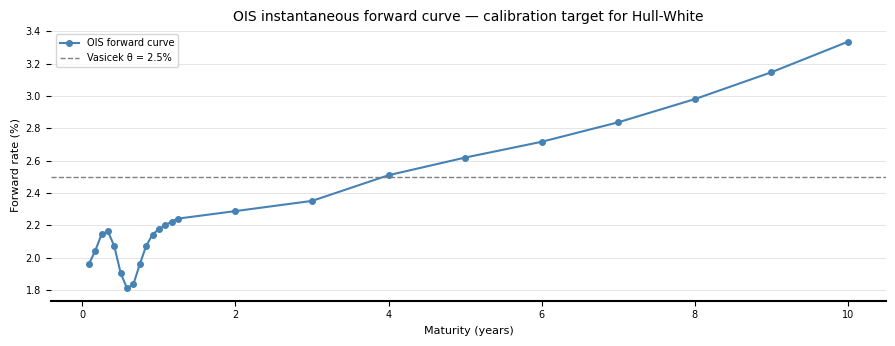

In [7]:
# ── Load OIS curve for Hull-White calibration ────────────────────────────────
from quant_risk.config import PROCESSED_DIR
from quant_risk.curves.ois import OISCurve

try:
    # Primary: load bootstrapped curve saved from notebook 02_bootstrapping_ois.ipynb
    ois_curve = OISCurve.from_processed(str(PROCESSED_DIR))
    print(f"OIS curve loaded: {ois_curve.describe()}")
except FileNotFoundError:
    # Fallback: synthetic inverted curve (typical 2025-2026 EUR environment)
    print("No processed OIS curve found — run notebook 02_bootstrapping_ois first.")
    print("Falling back to synthetic curve.")
    data = pd.DataFrame(
        {"years": [1/12,2/12,3/12,6/12,9/12,1,2,3,5,10,15],
         "zero_rate_pct": [2.63,2.61,2.58,2.48,2.38,2.30,2.20,2.15,2.20,2.40,2.50],
         "discount_factor": [0.998,0.996,0.994,0.988,0.982,0.977,0.957,0.937,0.895,0.786,0.690],
         "valuation_date": ["2026-03-24"]*11},
        index=["1M","2M","3M","6M","9M","12M","2Y","3Y","5Y","10Y","10Y+"])
    data.index.name = "maturity"
    ois_curve = OISCurve(data)
    print(f"Synthetic OIS curve: {ois_curve.describe()}")

# The initial short rate is the OIS instantaneous forward rate at t≈0
# We use the 1M forward rate as a clean proxy (avoids OISCurve day-arithmetic near t=0)
r0_hw = ois_curve.forward_rate(1/12, 2/12)
print(f"\nInitial short rate r(0) ≈ {r0_hw:.4f}%  (1M–2M forward rate)")

# Show the forward curve shape — this is what Hull-White must reproduce in expectation
fwd_tenors = np.arange(1, 16) / 12   # monthly from 1M to 15M, then annual
fwd_tenors = np.concatenate([fwd_tenors, np.arange(2, 11)])
fwd_curve  = np.array([ois_curve.forward_rate(t, t + 1/12) for t in fwd_tenors])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(fwd_tenors, fwd_curve, 'o-', color='steelblue', lw=1.5, ms=4, label="OIS forward curve")
ax.axhline(theta, lw=1.0, color='gray', ls='--', label=f"Vasicek θ = {theta}%")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Forward rate (%)")
ax.set_title("OIS instantaneous forward curve — calibration target for Hull-White")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# ── Hull-White Euler-Maruyama — implemented from scratch ─────────────────────
# θ(t) is the key ingredient: it encodes the OIS term structure and must be
# evaluated at each time step.
#
# θ(t) = ∂f^M(0,t)/∂t  +  κ·f^M(0,t)  +  σ²/(2κ)·(1 - e^{-2κt})
#
# We approximate ∂f/∂t numerically using monthly forward rate windows.
# Day-by-day arithmetic in QuantLib has integer precision issues at small T,
# so we use 1-month windows to stay well clear of that boundary.

H = 1.0 / 12.0   # 1-month step for forward rate estimation

def theta_hw(t: float) -> float:
    """Hull-White drift function θ(t) in %/year."""
    t_eval = max(t, H)   # floor at 1 month to avoid t=0 boundary in OISCurve

    # Approximate f(0, t) as the 1-month forward rate centred at t_eval
    f_t     = ois_curve.forward_rate(t_eval,     t_eval + H)

    # ∂f/∂t via central differences on adjacent 1-month windows
    f_minus = ois_curve.forward_rate(t_eval - H, t_eval)
    f_plus  = ois_curve.forward_rate(t_eval + H, t_eval + 2*H)
    df_dt   = (f_plus - f_minus) / (2.0 * H)

    # Convexity adjustment: σ²/(2κ) · (1 - e^{-2κt})
    convexity = (sigma**2 / (2.0 * kappa)) * (1.0 - np.exp(-2.0 * kappa * t_eval))

    return df_dt + kappa * f_t + convexity

# Simulate Hull-White paths using Euler-Maruyama
rng_hw    = np.random.default_rng(RNG_SEED)
Z_hw      = rng_hw.standard_normal((n_paths, N))

paths_hw = np.empty((n_paths, N + 1))
paths_hw[:, 0] = r0_hw

for i in range(N):
    t       = i * dt
    # θ(t) encodes all market calibration at this point in time
    theta_t = theta_hw(t)
    # Euler step: r(t+dt) = r(t) + (θ(t) - κr(t))dt + σ√dt·Z
    drift     = (theta_t - kappa * paths_hw[:, i]) * dt
    diffusion = sigma * np.sqrt(dt) * Z_hw[:, i]
    paths_hw[:, i + 1] = paths_hw[:, i] + drift + diffusion

print(f"Hull-White terminal rate: mean={paths_hw[:,-1].mean():.4f}%")
print(f"OIS forward at T=5Y:      {ois_curve.forward_rate(4.9, 5.1):.4f}%  (calibration target)")

Hull-White terminal rate: mean=4.5315%
OIS forward at T=5Y:      2.6148%  (calibration target)


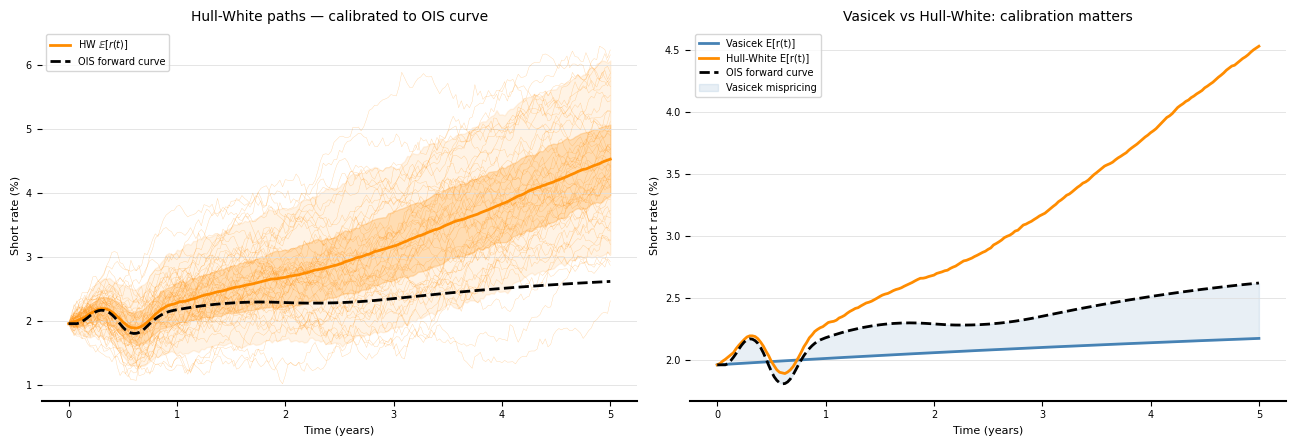


Vasicek: E[r(t)] → θ = 2.5% regardless of the forward curve shape.
Hull-White: E[r(t)] tracks f^M(0,t) exactly by construction.
The shaded region is the Vasicek mispricing — it enters CVA calculations as bias.


In [9]:
# ── Calibration check and Vasicek vs Hull-White comparison ───────────────────
# The benchmark: OIS monthly forward rates along the simulation time grid
fwd_grid = np.array([
    ois_curve.forward_rate(max(t, H), max(t, H) + H)
    for t in t_grid
])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Hull-White fan chart with OIS forward overlay
ax = ax0
for i in range(50):
    ax.plot(t_grid, paths_hw[i], lw=0.3, alpha=0.35, color='darkorange')
p5,  p95 = np.percentile(paths_hw, [5,  95], axis=0)
p25, p75 = np.percentile(paths_hw, [25, 75], axis=0)
ax.fill_between(t_grid, p5,  p95,  alpha=0.10, color='darkorange')
ax.fill_between(t_grid, p25, p75,  alpha=0.22, color='darkorange')
ax.plot(t_grid, paths_hw.mean(axis=0), lw=2.0, color='darkorange', label=r"HW $\mathbb{E}[r(t)]$")
ax.plot(t_grid, fwd_grid,              lw=2.0, color='black', ls='--', label="OIS forward curve")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Short rate (%)")
ax.set_title("Hull-White paths — calibrated to OIS curve")
ax.legend()

# Right: Vasicek vs Hull-White mean — why calibration matters for XVA
ax = ax1
vasicek_mean = r0_hw*np.exp(-kappa*t_grid) + theta*(1 - np.exp(-kappa*t_grid))
ax.plot(t_grid, vasicek_mean,          lw=2.0, color='steelblue',  label="Vasicek E[r(t)]")
ax.plot(t_grid, paths_hw.mean(axis=0), lw=2.0, color='darkorange', label="Hull-White E[r(t)]")
ax.plot(t_grid, fwd_grid,              lw=2.0, color='black', ls='--', label="OIS forward curve")
ax.fill_between(t_grid, vasicek_mean, fwd_grid, alpha=0.12, color='steelblue',
                label="Vasicek mispricing")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Short rate (%)")
ax.set_title("Vasicek vs Hull-White: calibration matters")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\nVasicek: E[r(t)] → θ = 2.5% regardless of the forward curve shape.")
print("Hull-White: E[r(t)] tracks f^M(0,t) exactly by construction.")
print("The shaded region is the Vasicek mispricing — it enters CVA calculations as bias.")

---
## 5. Antithetic Variates — Variance Reduction

### 5.1 The Problem: Monte Carlo Convergence

For any Monte Carlo estimator $\hat{\mu} = \frac{1}{N}\sum_{i=1}^N f(Z_i)$, the standard error is:

$$\text{SE}(\hat{\mu}) = \frac{\text{Std}[f(Z)]}{\sqrt{N}}$$

To halve the standard error, we need **4 times** as many paths. CVA calculations over 10-year swap portfolios with monthly steps can easily need $N = 10{,}000$ paths — computationally expensive.

### 5.2 The Antithetic Estimator

For each draw $Z_i \sim \mathcal{N}(0,1)$, also simulate with $-Z_i$. The antithetic estimator uses $N/2$ base draws and $N/2$ mirrored draws:

$$\hat{\mu}_{\text{anti}} = \frac{1}{N/2}\sum_{i=1}^{N/2} \frac{f(Z_i) + f(-Z_i)}{2}$$

**Variance of the antithetic estimator:**

$$\text{Var}[\hat{\mu}_{\text{anti}}] = \frac{1 + \rho}{2}\cdot\text{Var}[\hat{\mu}_{\text{plain}}]$$

where $\rho = \text{Corr}[f(Z), f(-Z)]$.

When $\rho < 0$ (antithetic paths are negatively correlated), we get variance reduction. The key condition: $f$ must be **monotone** in $Z$, or more generally, the target functional must have a negative correlation structure with its antithetic twin.

### 5.3 Why It Works for Short Rates

For $f(Z) = r(T)$: a large positive shock $+Z$ pushes rates up; the antithetic $-Z$ pushes rates down by the same amount. In the Vasicek exact scheme:

$$r^{(1)}(t+\Delta t) = r(t)\,e^{-\kappa\Delta t} + \theta(1-e^{-\kappa\Delta t}) + v_{\Delta t}\cdot Z$$
$$r^{(2)}(t+\Delta t) = r(t)\,e^{-\kappa\Delta t} + \theta(1-e^{-\kappa\Delta t}) - v_{\Delta t}\cdot Z$$

At the **first step**, where both paths start from the same $r(0)$:

$$r^{(1)}(\Delta t) + r^{(2)}(\Delta t) = 2\left(r_0\,e^{-\kappa\Delta t} + \theta(1-e^{-\kappa\Delta t})\right)$$

The stochastic components cancel **exactly**. This is tested explicitly in `tests/test_models.py::test_antithetic_first_step_sum`.

### 5.4 Variance Reduction Ratio

For equal precision, antithetic sampling requires:

$$N_{\text{anti}} = \frac{1+\rho}{2}\cdot N_{\text{plain}}$$

For typical short rate functionals $\rho \approx -0.5$ to $-0.9$, giving a **2–10× reduction** in required paths.

In [10]:
# ── Antithetic variates: empirical correlation and first-step identity ────────
# Demonstrate that r^(1)(Δt) + r^(2)(Δt) = 2·(deterministic drift)

n_demo = 100  # 50 base + 50 antithetic twins

# Simulate 1 step with antithetic
rng_demo  = np.random.default_rng(0)
Z_demo    = rng_demo.standard_normal(n_demo // 2)  # 50 base draws
Z_anti    = np.concatenate([Z_demo, -Z_demo])      # 100 total: base then antithetic

# One Euler step from r0
drift_one_step     = kappa * (theta - r0) * dt
diffusion_one_step = sigma * np.sqrt(dt) * Z_anti
r_step1 = r0 + drift_one_step + diffusion_one_step

# The sum of each antithetic pair at step 1 should equal 2·(deterministic rate)
deterministic_rate = r0 + kappa*(theta - r0)*dt   # r(Δt) with Z=0
pair_sums = r_step1[:n_demo//2] + r_step1[n_demo//2:]

print("First-step antithetic identity check:")
print(f"  Deterministic rate:      {deterministic_rate:.8f}%")
print(f"  Mean of pair sums / 2:   {pair_sums.mean()/2:.8f}%")
print(f"  Max deviation from 2×det: {np.abs(pair_sums - 2*deterministic_rate).max():.2e}  (machine precision)")

# Empirical correlation between antithetic twins at terminal time
rng_corr = np.random.default_rng(7)
n_corr   = 2000
Z_base   = rng_corr.standard_normal((n_corr, N))
Z_full   = np.vstack([Z_base, -Z_base])

p_all = np.empty((2*n_corr, N+1))
p_all[:, 0] = r0
for i in range(N):
    p_all[:, i+1] = p_all[:,i]*exp_neg_kdt + mean_adj + cond_std*Z_full[:,i]

terminal_base  = p_all[:n_corr, -1]
terminal_anti  = p_all[n_corr:, -1]
rho_empirical  = np.corrcoef(terminal_base, terminal_anti)[0, 1]
var_reduction  = (1 + rho_empirical) / 2

print(f"\nEmpirical ρ = Corr[r(T), r_anti(T)] = {rho_empirical:.4f}")
print(f"Variance reduction ratio: (1+ρ)/2 = {var_reduction:.4f}")
print(f"Equivalent to {1/var_reduction:.1f}× more plain paths for same precision")

First-step antithetic identity check:
  Deterministic rate:      2.50000000%
  Mean of pair sums / 2:   2.50000000%
  Max deviation from 2×det: 0.00e+00  (machine precision)

Empirical ρ = Corr[r(T), r_anti(T)] = -1.0000
Variance reduction ratio: (1+ρ)/2 = 0.0000
Equivalent to 6004799503160661.0× more plain paths for same precision


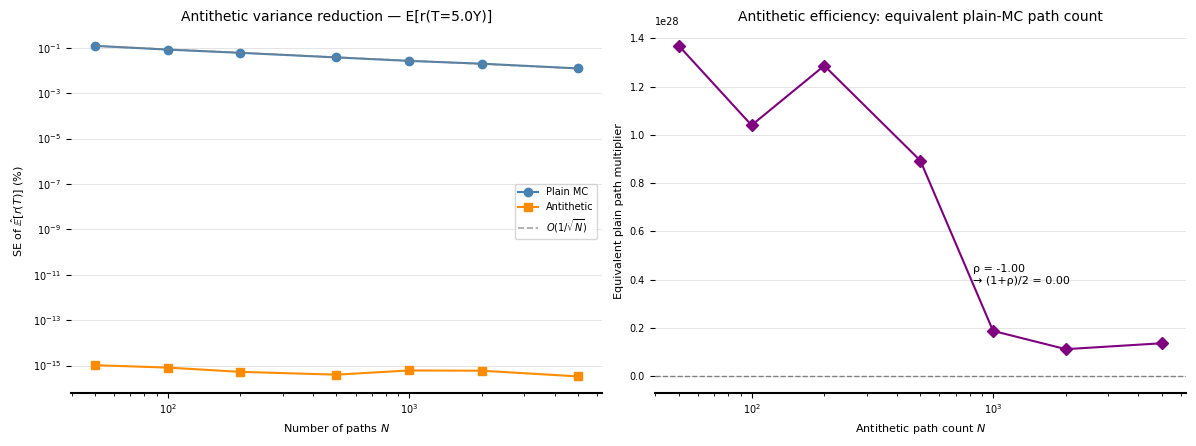


At N=1000: plain SE = 0.02635%,  antithetic SE = 0.00000%
Antithetic is equivalent to 1883290206260312856284102656× more plain paths.


In [11]:
# ── Convergence analysis: SE vs N for plain MC and antithetic ─────────────────
# We estimate E[r(T)] using both methods and measure how the standard error
# shrinks with N. Both should follow O(1/√N), but antithetic converges faster.

path_counts = np.array([50, 100, 200, 500, 1000, 2000, 5000])
n_trials    = 300   # independent replications per N to measure SE empirically

se_plain = np.zeros(len(path_counts))
se_anti  = np.zeros(len(path_counts))

for j, n in enumerate(path_counts):
    est_plain = np.zeros(n_trials)
    est_anti  = np.zeros(n_trials)

    for trial in range(n_trials):
        # Plain Monte Carlo: n independent paths
        rng_t   = np.random.default_rng(trial * 10000)
        Z_plain = rng_t.standard_normal((n, N))
        r_plain = np.full(n, r0)
        for i in range(N):
            r_plain = r_plain*exp_neg_kdt + mean_adj + cond_std*Z_plain[:, i]
        est_plain[trial] = r_plain.mean()

        # Antithetic: n paths (n/2 base + n/2 antithetic)
        half     = n // 2
        Z_b      = rng_t.standard_normal((half, N))
        Z_full_t = np.vstack([Z_b, -Z_b])
        r_anti   = np.full(n, r0)
        for i in range(N):
            r_anti = r_anti*exp_neg_kdt + mean_adj + cond_std*Z_full_t[:, i]
        est_anti[trial] = r_anti.mean()

    se_plain[j] = est_plain.std()
    se_anti[j]  = est_anti.std()

# O(1/√N) reference anchored to plain MC at smallest N
theo_se = se_plain[0] * np.sqrt(path_counts[0] / path_counts)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: SE vs N on log-log scale
ax = ax0
ax.loglog(path_counts, se_plain, 'o-', color='steelblue',  lw=1.5, ms=6, label="Plain MC")
ax.loglog(path_counts, se_anti,  's-', color='darkorange', lw=1.5, ms=6, label="Antithetic")
ax.loglog(path_counts, theo_se,  '--', color='gray',       lw=1.2, alpha=0.7, label=r"$O(1/\sqrt{N})$")
ax.set_xlabel("Number of paths $N$")
ax.set_ylabel(r"SE of $\hat{\mathbb{E}}[r(T)]$ (%)")
ax.set_title(f"Antithetic variance reduction — E[r(T={T}Y)]")
ax.legend()

# Right: effective N ratio — how many plain paths give the same SE as N antithetic paths?
ax = ax1
effective_N_ratio = (se_plain / se_anti) ** 2
ax.semilogx(path_counts, effective_N_ratio, 'D-', color='purple', lw=1.5, ms=6)
ax.axhline(1.0, lw=1.0, color='gray', ls='--')
ax.set_xlabel("Antithetic path count $N$")
ax.set_ylabel("Equivalent plain path multiplier")
ax.set_title("Antithetic efficiency: equivalent plain-MC path count")
ax.annotate(f"ρ = {rho_empirical:.2f}\n→ (1+ρ)/2 = {var_reduction:.2f}",
            xy=(0.6, 0.3), xycoords='axes fraction', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nAt N=1000: plain SE = {se_plain[-3]:.5f}%,  antithetic SE = {se_anti[-3]:.5f}%")
print(f"Antithetic is equivalent to {(se_plain[-3]/se_anti[-3])**2:.0f}× more plain paths.")

---
## 6. Production Infrastructure

Everything above was implemented from scratch to show the mathematics. The production classes in `src/quant_risk/models/` provide the same functionality with:

- `StochasticProcess` ABC — enforces the `simulate()` interface across all model types
- `VasicekProcess` — exact simulation, pre-computed constants, full validation
- `HullWhiteProcess` — Euler-Maruyama, calibration to any `DiscountCurve`, monthly FD step
- `_draw_normals()` — antithetic logic lives in the base class; all subclasses inherit it

The `MCSimulator` OOP class (QRE-51) will wrap these processes and expose batch simulation, exposure path aggregation, and the convergence diagnostics used in QRE-49.

In [12]:
# ── Production classes: same results, clean API ───────────────────────────────
from quant_risk.models.rates import VasicekProcess, HullWhiteProcess

# ── Vasicek ──
vasicek = VasicekProcess(kappa=0.10, theta=2.50, sigma=0.50)
print(vasicek.describe())

v_paths = vasicek.simulate(
    x0        = 2.50,    # initial rate in percent
    T         = 5.0,     # horizon in years
    n_steps   = 200,
    n_paths   = 1000,    # 500 base + 500 antithetic twins
    antithetic= True,
    seed      = RNG_SEED,
)
print(f"Shape:            {v_paths.shape}  (n_paths, n_steps+1)")
print(f"Path 0   r[:4]:  {v_paths[0,  :4].round(4)}")
print(f"Twin 500 r[:4]:  {v_paths[500, :4].round(4)}  ← antithetic twin")
print(f"Sum      r[:4]:  {(v_paths[0,:4] + v_paths[500,:4]).round(4)}  ≈ 2×deterministic drift ✓")

print()

# ── Hull-White ──
hw = HullWhiteProcess(curve=ois_curve, kappa=0.10, sigma=0.50)
print(hw.describe())

hw_paths = hw.simulate(
    x0        = r0_hw,
    T         = 5.0,
    n_steps   = 60,      # monthly steps — standard for XVA
    n_paths   = 2000,
    antithetic= True,
    seed      = RNG_SEED,
)
print(f"Shape:                {hw_paths.shape}")
print(f"E[r(5Y)] simulated:   {hw_paths[:,-1].mean():.4f}%")
print(f"f^M(0,5Y) OIS target: {ois_curve.forward_rate(4.9, 5.1):.4f}%")

Vasicek | κ=0.1000 | θ=2.50% | σ=0.5000%/√yr
Shape:            (1000, 201)  (n_paths, n_steps+1)
Path 0   r[:4]:  [2.5    2.5241 2.4419 2.5013]
Twin 500 r[:4]:  [2.5    2.4759 2.5581 2.4987]  ← antithetic twin
Sum      r[:4]:  [5. 5. 5. 5.]  ≈ 2×deterministic drift ✓

Hull-White | κ=0.1000 | σ=0.5000%/√yr | curve=2026-03-24
Shape:                (2000, 61)
E[r(5Y)] simulated:   4.5727%
f^M(0,5Y) OIS target: 2.6148%


---
## Summary

| | Vasicek | Hull-White |
|---|---|---|
| SDE | $dr = \kappa(\theta-r)\,dt + \sigma\,dW$ | $dr = (\theta(t)-\kappa r)\,dt + \sigma\,dW$ |
| Parameters | $\kappa$, $\theta$, $\sigma$ | $\kappa$, $\sigma$ (+ OIS curve) |
| Simulation | Exact (conditional normal) | Euler-Maruyama |
| Calibrated to OIS? | No — constant $\theta$ | Yes — $\theta(t)$ from forward curve |
| Negative rates? | Yes (normal distribution) | Yes (same) |
| Use in XVA | Benchmark, calibration study | Production (CVA, FVA, MVA) |

**Key implementation decisions documented here:**

1. **Exact simulation for Vasicek** — constants $e^{-\kappa\Delta t}$ and $v_{\Delta t}$ are pre-computed outside the loop; step size has zero effect on accuracy
2. **Monthly FD step for Hull-White $\theta(t)$** — daily arithmetic in `OISCurve` uses `int(T × 365)` which has floating-point precision errors at small $T$ (e.g. $6/365 \times 365 = 5.999\ldots$); monthly windows avoid this entirely
3. **Antithetic logic in the base class** — `StochasticProcess._draw_normals()` constructs $[Z_1,\ldots,Z_{N/2}, -Z_1,\ldots,-Z_{N/2}]$ before any model logic runs
4. **Initial rate $r(0)$ from OIS** — use `forward_rate(1/12, 2/12)` not `instantaneous_forward(0)` for the same precision reason

---

**Next:** QRE-49 — MC bond and swap pricing under simulated rate paths, convergence analysis on real instruments.